++Facial Emotion Recognition (FER) using CNN

1. Project Setup


In [32]:
import os

# ---- Your dataset is already extracted here (WSL path) ----
project_dir = "/mnt/d/FER_new"
# --------------------------------------------------------------

os.makedirs(os.path.join(project_dir, "models"), exist_ok=True)
print("Project dir:", project_dir)
print(os.listdir(project_dir))


Project dir: /mnt/d/FER_new
['D:\\FER_new', 'FER_CNN_Project_LOCAL.ipynb', 'models', 'test', 'train', 'val']


In [33]:
# Dataset already extracted directly into D:\FER_new\train, \test, \val
# (no zip extraction step needed)

extract_path = project_dir

print("train classes:", os.listdir(os.path.join(extract_path, "train")))
print("test classes:", os.listdir(os.path.join(extract_path, "test")))


train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [34]:
print(os.listdir(extract_path))


['D:\\FER_new', 'FER_CNN_Project_LOCAL.ipynb', 'models', 'test', 'train', 'val']


In [35]:
print(os.listdir(os.path.join(extract_path, "train")))
print(os.listdir(os.path.join(extract_path, "test")))


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [36]:
happy_images = os.listdir(os.path.join(extract_path, "train", "happy"))
print(len(happy_images))


6472


In [37]:
emotions = ["angry","fear","surprise","happy","sad","disgust","neutral"]
for emotion in emotions:
    folder_path = os.path.join(extract_path, "train", emotion)
    images = os.listdir(folder_path)
    print(emotion, len(images))


angry 6472
fear 6472
surprise 6472
happy 6472
sad 6472
disgust 6472
neutral 6472


In [38]:
total_train_images = 0
emotions = ["angry","fear","surprise","happy","sad","disgust","neutral"]
for emotion in emotions:
    folder_path = os.path.join(extract_path, "train", emotion)
    images = os.listdir(folder_path)
    total_train_images += len(images)
print("total_train_images:", total_train_images)


total_train_images: 45304


In [39]:
total_test_images = 0
for emotion in emotions:
    folder_path = os.path.join(extract_path, "test", emotion)
    images = os.listdir(folder_path)
    print(emotion, len(images))
    total_test_images += len(images)
print("total_test_images", total_test_images)


angry 898
fear 898
surprise 898
happy 898
sad 898
disgust 898
neutral 898
total_test_images 6286


In [40]:
import matplotlib.pyplot as plt

In [41]:
happy_folder = os.path.join(extract_path, "train", "happy")
happy_images = os.listdir(happy_folder)
print(happy_images[0])


100.jpg


In [42]:
image_path = happy_folder + "/" + happy_images[0]
print(image_path)

/mnt/d/FER_new/train/happy/100.jpg


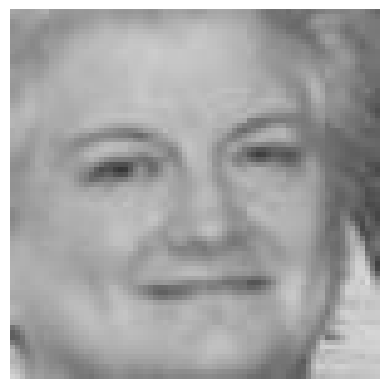

In [43]:
image = plt.imread(image_path)
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [44]:
print(image.shape)
print(image)

(75, 75, 3)
[[[165 165 165]
  [163 163 163]
  [160 160 160]
  ...
  [120 120 120]
  [113 113 113]
  [104 104 104]]

 [[157 157 157]
  [157 157 157]
  [158 158 158]
  ...
  [123 123 123]
  [119 119 119]
  [113 113 113]]

 [[146 146 146]
  [150 150 150]
  [155 155 155]
  ...
  [124 124 124]
  [122 122 122]
  [121 121 121]]

 ...

 [[189 189 189]
  [183 183 183]
  [166 166 166]
  ...
  [200 200 200]
  [202 202 202]
  [203 203 203]]

 [[200 200 200]
  [193 193 193]
  [176 176 176]
  ...
  [197 197 197]
  [199 199 199]
  [201 201 201]]

 [[210 210 210]
  [203 203 203]
  [184 184 184]
  ...
  [194 194 194]
  [196 196 196]
  [198 198 198]]]


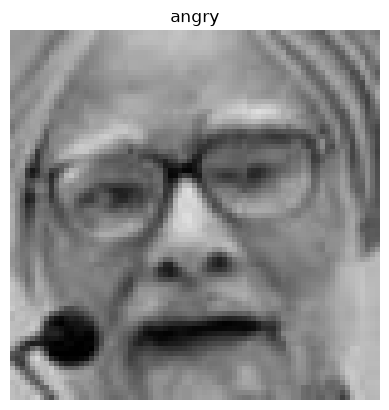

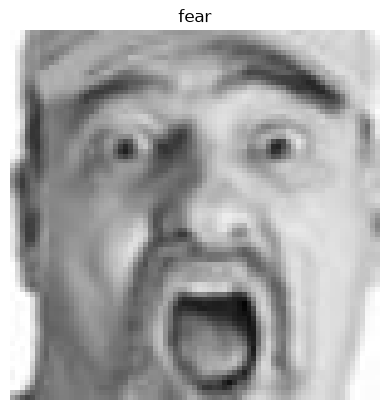

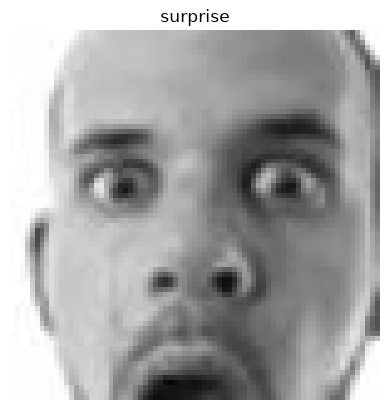

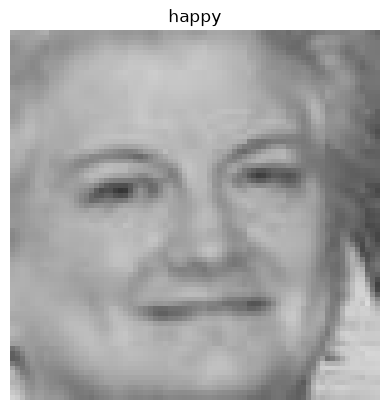

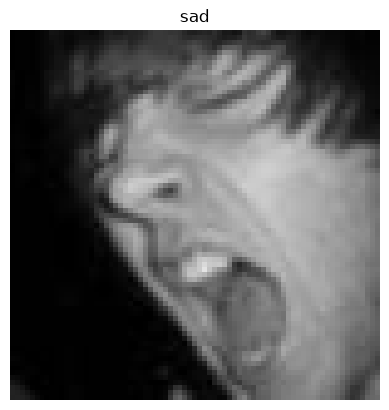

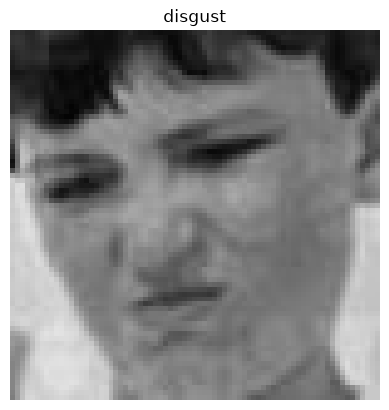

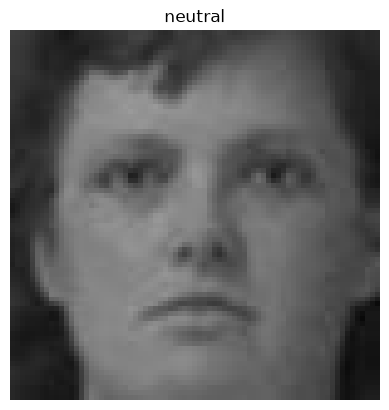

In [45]:
for emotion in emotions:
    folder_path = os.path.join(extract_path, "train", emotion)
    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    image = plt.imread(image_path)
    plt.imshow(image, cmap="gray")
    plt.title(emotion)
    plt.axis("off")
    plt.show()


[6472, 6472, 6472, 6472, 6472, 6472, 6472]


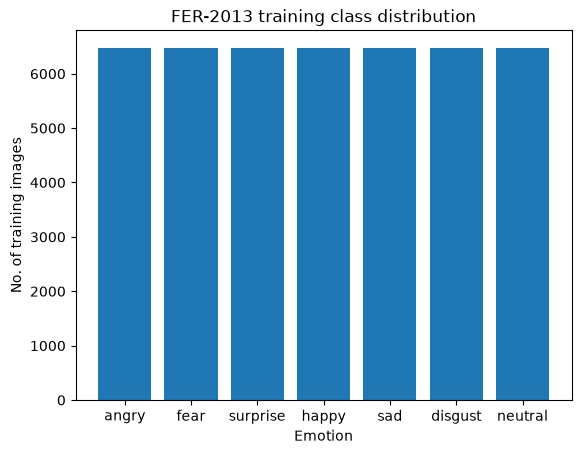

In [46]:
train_counts = []
for emotion in emotions:
    folder_path = os.path.join(extract_path, "train", emotion)
    images = os.listdir(folder_path)
    train_counts.append(len(images))
print(train_counts)

plt.bar(emotions, train_counts)
plt.xlabel("Emotion")
plt.ylabel("No. of training images")
plt.title("FER-2013 training class distribution")
plt.show()


In [47]:
print("shape:", image.shape)
print("Data Type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum Pixel Value:", image.max())

shape: (75, 75, 3)
Data Type: uint8
Minimum pixel value: 9
Maximum Pixel Value: 154


In [48]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [49]:
train_path = os.path.join(extract_path, "train")
val_path = os.path.join(extract_path, "val")
test_path = os.path.join(extract_path, "test")
image_size = (48, 48)
batch_size = 32


In [50]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)


Found 45304 files belonging to 7 classes.


In [51]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)


Found 11326 files belonging to 7 classes.


In [52]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size = image_size,
    batch_size = batch_size,
    color_mode = "grayscale",
    shuffle = False
)

Found 6286 files belonging to 7 classes.


In [53]:
print(train_dataset.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [54]:
for images, labels in train_dataset.take(1):
  print("Image shape:", images.shape)
  print("labels shape:", labels.shape)
  print("labels:", labels)

Image shape: (32, 48, 48, 1)
labels shape: (32,)
labels: tf.Tensor([0 0 0 3 6 5 6 6 4 0 3 1 2 4 3 5 3 2 5 2 6 4 5 4 1 0 3 3 5 6 5 5], shape=(32,), dtype=int32)


numeric label: 0
emotion name: angry


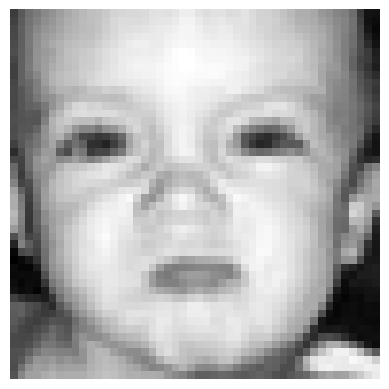

In [55]:
for images, labels in train_dataset.take(1):
  first_image = images[0]
  first_label = labels[0]
  print("numeric label:", first_label.numpy())
  print("emotion name:", train_dataset.class_names[first_label.numpy()])
  plt.imshow(first_image.numpy().squeeze(), cmap= "gray")
  plt.axis("off")
  plt.show()

In [56]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [57]:
normalized_image = normalization_layer(first_image)

print("before normalization")
print("minimum:",tf.reduce_min(first_image).numpy())
print("maximum:",tf.reduce_max(first_image).numpy())

print("\n after normalization")
print("minimum", tf.reduce_min(normalized_image).numpy())
print("maximum", tf.reduce_max(normalized_image).numpy())

before normalization
minimum: 3.6298828
maximum: 221.0

 after normalization
minimum 0.014234835
maximum 0.86666673


In [58]:
print("training classses:",train_dataset.class_names)
print("validation classes:", validation_dataset.class_names)
print("test classes:", test_dataset.class_names)

training classses: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
validation classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [59]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48,48,1)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(
    32,
    (3,3),
    activation = "relu",
    padding = "same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size = (2,2)
    ),
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation = "relu",
        padding = "same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size = (2,2)
    ),
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation = "relu",
        padding = "same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2,2)
    ),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        7,
        activation="softmax"
    )
])

In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [62]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


I0000 00:00:1789241234.569104    9751 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7478__.40


1415/1416 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2919 - loss: 1.7693

I0000 00:00:1789241274.268049    9752 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7478__.40


1416/1416 ━━━━━━━━━━━━━━━━━━━━ 62s 42ms/step - accuracy: 0.2920 - loss: 1.7691 - val_accuracy: 0.4330 - val_loss: 1.5046
Epoch 2/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 70s 49ms/step - accuracy: 0.4555 - loss: 1.4388 - val_accuracy: 0.5224 - val_loss: 1.2748
Epoch 3/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.5185 - loss: 1.2750 - val_accuracy: 0.5617 - val_loss: 1.1639
Epoch 4/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.5579 - loss: 1.1666 - val_accuracy: 0.5918 - val_loss: 1.0912
Epoch 5/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.5886 - loss: 1.0892 - val_accuracy: 0.6061 - val_loss: 1.0510
Epoch 6/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6132 - loss: 1.0169 - val_accuracy: 0.6198 - val_loss: 1.0275
Epoch 7/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6358 - loss: 0.9580 - val_accuracy: 0.6244 - val_loss: 1.0251
Epoch 8/10
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6510 - loss: 0.91

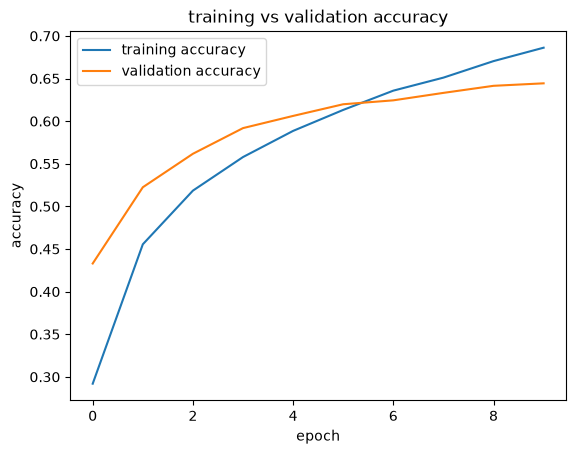

In [63]:
plt.plot(history.history["accuracy"],label="training accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("training vs validation accuracy")
plt.legend()
plt.show()

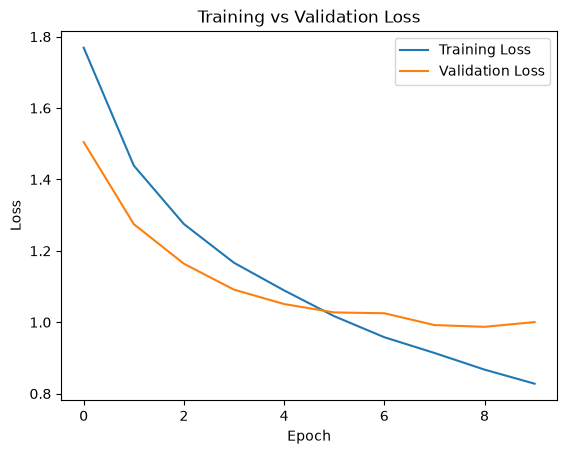

In [64]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [65]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print("test Loss:", test_loss)
print("test accuracy:", test_accuracy)
print("test accuracy(%):", test_accuracy*100)

197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6392 - loss: 1.0278
test Loss: 1.027777075767517
test accuracy: 0.6391982436180115
test accuracy(%): 63.91982436180115


In [66]:
predictions = model.predict(test_dataset)
print(predictions.shape)
print("first predictions",predictions[0])

197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
(6286, 7)
first predictions [8.3850378e-01 2.2191535e-09 1.4733110e-01 1.2528766e-02 1.5067036e-06
 4.4412291e-06 1.6304632e-03]


In [67]:
import numpy as np
predicted_label = np.argmax(predictions[0])
predicted_emotion = test_dataset.class_names[predicted_label]
print("predicted nuumeric label:", predicted_label)
print("predicted emotion:", predicted_emotion)

predicted nuumeric label: 0
predicted emotion: angry


In [68]:
predicted_labels = np.argmax(predictions, axis=1)
print("predicted labels shape:", predicted_labels.shape)
print("First 10 predicted labels:", predicted_labels[:10])

predicted labels shape: (6286,)
First 10 predicted labels: [0 0 4 0 2 3 0 0 0 5]


In [69]:
actual_labels = []

for images, labels in test_dataset:
    actual_labels.extend(labels.numpy())

actual_labels = np.array(actual_labels)

print("Actual labels shape:", actual_labels.shape)
print("First 10 actual labels:", actual_labels[:10])

Actual labels shape: (6286,)
First 10 actual labels: [0 0 0 0 0 0 0 0 0 0]


In [70]:
actual_labels = []

for images, labels in test_dataset:
    actual_labels.extend(labels.numpy())

actual_labels = np.array(actual_labels)

In [71]:
print("Predicted labels shape:", predicted_labels.shape)
print("Actual labels shape:", actual_labels.shape)

print("First 10 predicted:", predicted_labels[:10])
print("First 10 actual:", actual_labels[:10])

Predicted labels shape: (6286,)
Actual labels shape: (6286,)
First 10 predicted: [0 0 4 0 2 3 0 0 0 5]
First 10 actual: [0 0 0 0 0 0 0 0 0 0]


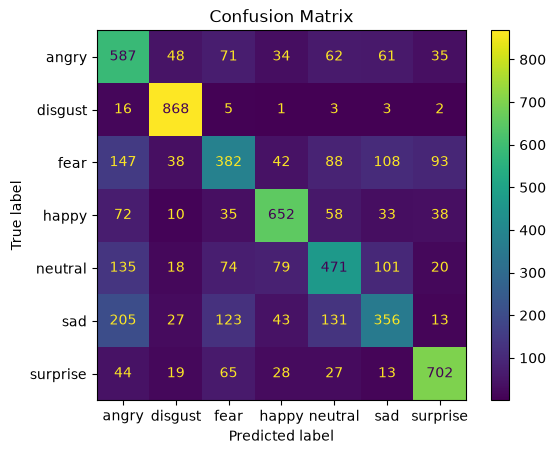

              precision    recall  f1-score   support

       angry       0.49      0.65      0.56       898
     disgust       0.84      0.97      0.90       898
        fear       0.51      0.43      0.46       898
       happy       0.74      0.73      0.73       898
     neutral       0.56      0.52      0.54       898
         sad       0.53      0.40      0.45       898
    surprise       0.78      0.78      0.78       898

    accuracy                           0.64      6286
   macro avg       0.63      0.64      0.63      6286
weighted avg       0.63      0.64      0.63      6286

Baseline model saved successfully: /mnt/d/FER_new/models/baseline_fer_model.keras


In [72]:
# =========================================================
# 1. CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(actual_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


# =========================================================
# 2. CLASSIFICATION REPORT
# Precision, Recall, F1-score
# =========================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=test_dataset.class_names
    )
)


# =========================================================
# 3. SAVE BASELINE MODEL
# =========================================================

baseline_model_path = os.path.join(project_dir, "models", "baseline_fer_model.keras")

model.save(baseline_model_path)

print("Baseline model saved successfully:", baseline_model_path)


## 2. Improved Model (Fixed Pipeline)

Baseline accuracy: ~65%. This section replaces the earlier improvement attempt with a single, clean pipeline:
- Dataset is class-balanced (verified: ~6472 images/class in train) → **no class_weight needed**, removed.
- Deeper CNN (4 conv blocks) + BatchNorm + GlobalAveragePooling (fewer params, less overfitting than Flatten+128 Dense).
- Stronger augmentation (flip, rotation, zoom, translation, contrast).
- L2 regularization + Dropout tuned per block.
- Label smoothing to reduce overconfidence on ambiguous emotions (e.g. fear vs surprise, disgust vs angry).
- EarlyStopping + ReduceLROnPlateau + ModelCheckpoint.
- Trained ONCE for up to 40 epochs (early stopping will cut it short) — no silent re-training on top of a previous run.

In [73]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")


In [74]:
from tensorflow.keras import regularizers

l2 = regularizers.l2(1e-4)

def conv_block(x, filters, dropout_rate):
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

inputs = tf.keras.layers.Input(shape=(48, 48, 1))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./255)(x)

x = conv_block(x, 64, 0.20)
x = conv_block(x, 128, 0.25)
x = conv_block(x, 256, 0.30)
x = conv_block(x, 256, 0.35)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=l2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(7, activation="softmax")(x)

improved_model = tf.keras.Model(inputs, outputs, name="fer_improved_cnn")
improved_model.summary()


Model: "fer_improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,398,663 (9.15 MB)

 Trainable params: 2,395,335 (9.14 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [75]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [76]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

best_model_path = os.path.join(project_dir, "models", "best_fer_model.keras")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model_checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_accuracy",
    save_best_only=True
)


In [77]:
# NOTE: trained once, no class_weight (dataset is already class-balanced),
# no re-fitting on top of a previous run.
improved_history = improved_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=40,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)


Epoch 1/40


/home/ujjwal/fer_env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789241637.192629    9579 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fer_improved_cnn_1/dropout_2_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1416/1416 ━━━━━━━━━━━━━━━━━━━━ 183s 120ms/step - accuracy: 0.1801 - loss: 2.2232 - val_accuracy: 0.2039 - val_loss: 2.0373 - learning_rate: 0.0010
Epoch 2/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 174s 123ms/step - accuracy: 0.3384 - loss: 1.8304 - val_accuracy: 0.3269 - val_loss: 2.1701 - learning_rate: 0.0010
Epoch 3/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 148s 104ms/step - accuracy: 0.4361 - loss: 1.6401 - val_accuracy: 0.4451 - val_loss: 1.6565 - learning_rate: 0.0010
Epoch 4/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 122s 86ms/step - accuracy: 0.4728 - loss: 1.5836 - val_accuracy: 0.4969 - val_loss: 1.5896 - learning_rate: 0.0010
Epoch 5/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 123s 87ms/step - accuracy: 0.4987 - loss: 1.5510 - val_accuracy: 0.5225 - val_loss: 1.4769 - learning_rate: 0.0010
Epoch 6/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.5159 - loss: 1.5331 - val_accuracy: 0.5059 - val_loss: 1.5943 - learning_rate: 0.0010
Epoch 7/40
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 122s 86ms/step - accurac

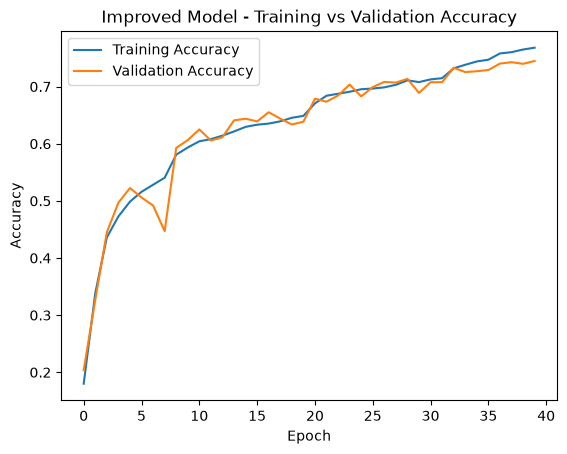

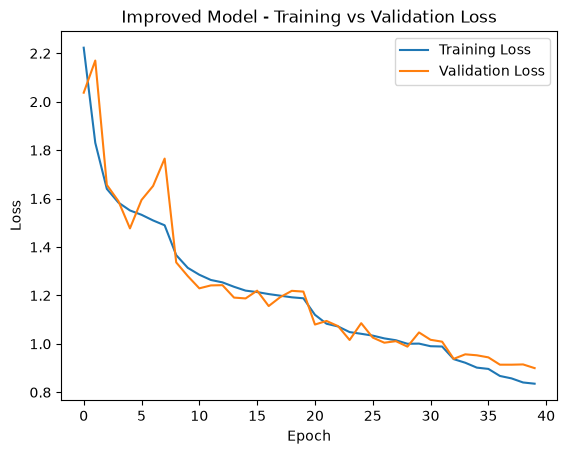

In [78]:
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Model - Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.plot(improved_history.history["loss"], label="Training Loss")
plt.plot(improved_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Model - Training vs Validation Loss")
plt.legend()
plt.show()


In [79]:
# Load the BEST checkpoint (highest val_accuracy), not just the final epoch's weights
final_model = tf.keras.models.load_model(best_model_path)

improved_test_loss, improved_test_accuracy = final_model.evaluate(test_dataset)
print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)
print("Improved Test Accuracy (%):", improved_test_accuracy * 100)


197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.7377 - loss: 0.9288
Improved Test Loss: 0.9288193583488464
Improved Test Accuracy: 0.7376710176467896
Improved Test Accuracy (%): 73.76710176467896


197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


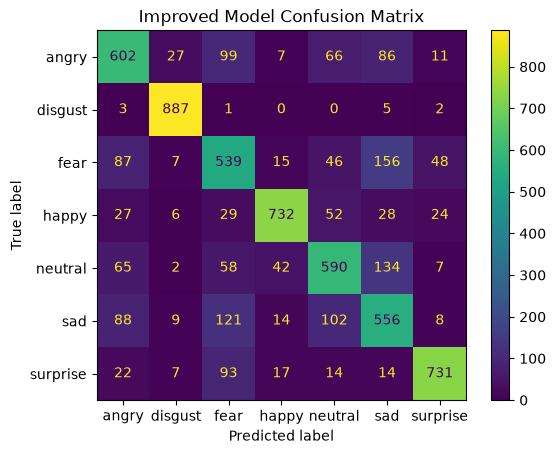

              precision    recall  f1-score   support

       angry       0.67      0.67      0.67       898
     disgust       0.94      0.99      0.96       898
        fear       0.57      0.60      0.59       898
       happy       0.89      0.82      0.85       898
     neutral       0.68      0.66      0.67       898
         sad       0.57      0.62      0.59       898
    surprise       0.88      0.81      0.85       898

    accuracy                           0.74      6286
   macro avg       0.74      0.74      0.74      6286
weighted avg       0.74      0.74      0.74      6286



In [80]:
improved_predictions = final_model.predict(test_dataset)
improved_predicted_labels = np.argmax(improved_predictions, axis=1)

improved_cm = confusion_matrix(actual_labels, improved_predicted_labels)
improved_disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=test_dataset.class_names
)
improved_disp.plot()
plt.title("Improved Model Confusion Matrix")
plt.show()

print(classification_report(
    actual_labels,
    improved_predicted_labels,
    target_names=test_dataset.class_names
))


## 3. Optional Next Step — Fine-tune with a Pretrained Backbone

If ~72-75% test accuracy from the CNN above isn't enough, the biggest further jump comes from transfer learning (e.g. a small pretrained backbone fine-tuned on 3-channel resized 48x48→96x96 grayscale-replicated images) rather than tweaking this from-scratch CNN further. From-scratch CNNs on FER2013-style data at 48x48 grayscale typically plateau around 70-73% test accuracy; published FER2013 leaderboards that reach 75%+ almost always use ensembles or pretrained backbones.

In [81]:
final_model_path = os.path.join(project_dir, "models", "final_fer_model.keras")
final_model.save(final_model_path)
print("Final model saved successfully!")
print(final_model_path)


Final model saved successfully!
/mnt/d/FER_new/models/final_fer_model.keras


In [82]:
import matplotlib.pyplot as plt
import numpy as np

def predict_emotion(image_path):
    image = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=(48, 48))
    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, axis=0)

    prediction = final_model.predict(image_array, verbose=0)
    predicted_label = np.argmax(prediction[0])
    predicted_emotion = test_dataset.class_names[predicted_label]
    confidence = prediction[0][predicted_label] * 100

    print("Predicted Emotion:", predicted_emotion)
    print("Confidence:", confidence, "%")

    plt.imshow(image, cmap="gray")
    plt.title(predicted_emotion)
    plt.axis("off")
    plt.show()


## 4. Live Webcam Emotion Detection

Real-time face detection (OpenCV Haar Cascade) + trained model se emotion prediction. Sirf local machine pe chalega (VS Code) — Colab/Kaggle mein webcam access kaam nahi karega.

**Controls:** window khulne ke baad `q` press karke band karo.

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf

project_dir = "/mnt/d/FER_new"

# Load trained model (change path if using a different saved model)
webcam_model_path = os.path.join(project_dir, "models", "final_fer_model.keras")
webcam_model = tf.keras.models.load_model(webcam_model_path)

class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# OpenCV's built-in face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Model loaded:", webcam_model_path)

I0000 00:00:1789276498.225377   89611 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model loaded: /mnt/d/FER_new/models/final_fer_model.keras


In [5]:
cap = cv2.VideoCapture(0)  # 0 = default webcam; change to 1/2 if you have multiple cameras

if not cap.isOpened():
    print("Could not open webcam. Check camera permissions / index.")
else:
    print("Webcam started. Press 'q' in the window to quit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        face_roi = gray[y:y + h, x:x + w]
        face_roi = cv2.resize(face_roi, (48, 48))
        face_input = face_roi.astype("float32")
        face_input = np.expand_dims(face_input, axis=-1)   # (48,48,1)
        face_input = np.expand_dims(face_input, axis=0)    # (1,48,48,1)

        prediction = webcam_model.predict(face_input, verbose=0)
        predicted_label = np.argmax(prediction[0])
        predicted_emotion = class_names[predicted_label]
        confidence = prediction[0][predicted_label] * 100

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        label_text = f"{predicted_emotion} ({confidence:.1f}%)"
        cv2.putText(
            frame, label_text, (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2
        )

    cv2.imshow("Live Emotion Detection - press q to quit", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


Could not open webcam. Check camera permissions / index.


[ WARN:0@160.673] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@160.674] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
